# Generate Deletion Figure

EDA

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
method1 = "attention_mask"
path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method1}/" \
f"02F4A1FB_left_curve_{method1}.npy")
data = np.load(path, allow_pickle=True).item()
print("columns in npy files"+str(list(data.keys())))
print("----")
print("label is " + str(data["predicted_class"]))
print("All confidences from deletion on each step"+str(data['predicted_confidences']))
#print("Confidences on class 2" + str(data['confidences'][:, -1:]))


columns in npy files['percentages', 'raw_logits', 'confidences', 'normalized_confidences', 'predicted_class', 'predicted_confidences', 'predicted_normalized_confidences', 'auc', 'baseline']
----
label is 2
All confidences from deletion on each step[0.5892136  0.42566192 0.858422   0.13975523 0.21523179 0.36638677
 0.4590295  0.33329442 0.4319318  0.41748074 0.3397712  0.24216439
 0.34374875 0.28210357 0.26604903 0.15785745 0.15690258 0.17287877
 0.6688593  0.6354381  0.39282265]


In [5]:
data['percentages']

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [10]:
method = "minimum-intensity"

#I would like to compare confidences on the same image in different evluation only on the percentages = 0
compare_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}/" \
f"02F4A1FB_left_curve_{method}.npy")
compare_data = np.load(compare_path, allow_pickle=True).item()


print(f"Method is {method}")
print("label is " + str(compare_data["predicted_class"]))
print("All confidences from deletion on each step "+str(compare_data['predicted_confidences'][0]))
print("Confidences on class 2 at 0% is " + str(compare_data['confidences'][0, 2]))

print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 2 at 0% is " + str(data['confidences'][0, 2]))


Method is minimum-intensity
label is 2
All confidences from deletion on each step 0.5890361
Confidences on class 2 at 0% is 0.5890361
----
Attention Mask
All confidences from deletion on each step 0.5892136
Confidences on class 2 at 0% is 0.5892136


In [11]:
method = "minimum-intensity"

#I would like to compare confidences on the same image in different evluation only on the percentages = 0
compare_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}/" \
f"02F4A1FB_left_curve_{method}.npy")
compare_data = np.load(compare_path, allow_pickle=True).item()


print(f"Method is {method}")
print("label is " + str(compare_data["predicted_class"]))
print("All confidences from deletion on each step "+str(compare_data['predicted_confidences'][0]))
print("Confidences on class 2 at 100% is " + str(compare_data['confidences'][20, 2]))

print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 2 at 100% is " + str(data['confidences'][20, 2]))


Method is minimum-intensity
label is 2
All confidences from deletion on each step 0.5890361
Confidences on class 2 at 100% is 0.8716452
----
Attention Mask
All confidences from deletion on each step 0.5892136
Confidences on class 2 at 100% is 0.39282265


In [8]:
print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 0 at 100% is " + str(data['confidences'][20, 0]))


print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 1 at 100% is " + str(data['confidences'][20, 1]))


print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 2 at 100% is " + str(data['confidences'][20, 2]))

----
Attention Mask
All confidences from deletion on each step 0.5892136
Confidences on class 0 at 100% is 0.60197854
----
Attention Mask
All confidences from deletion on each step 0.5892136
Confidences on class 1 at 100% is 0.005198791
----
Attention Mask
All confidences from deletion on each step 0.5892136
Confidences on class 2 at 100% is 0.39282265


it should be same why it's different

## Attention

### Overall

In [6]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




ValueError: need at least one array to stack

### Each Class

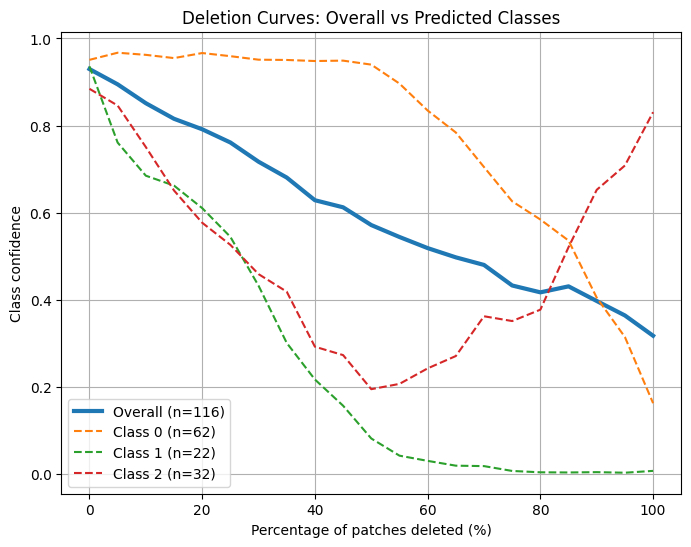

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


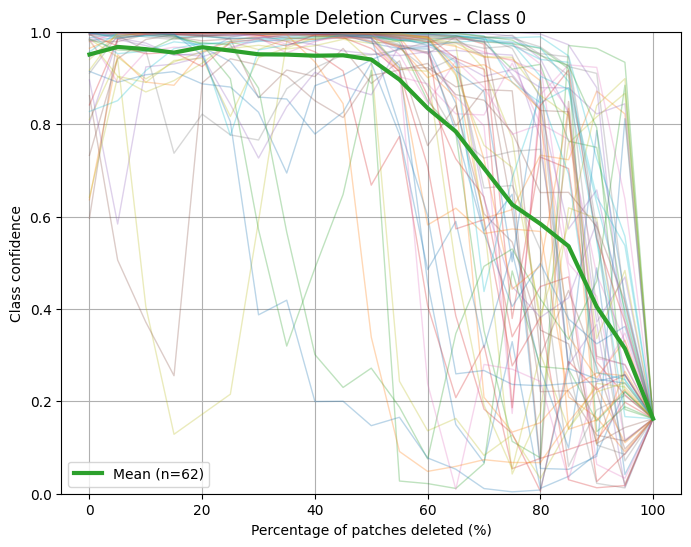

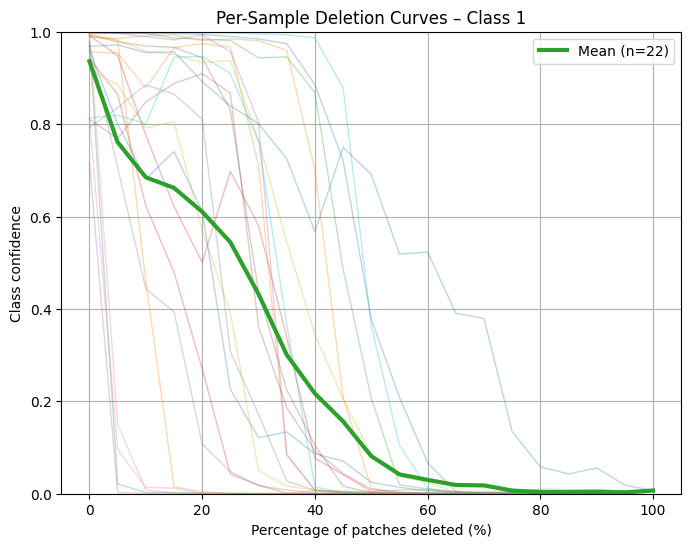

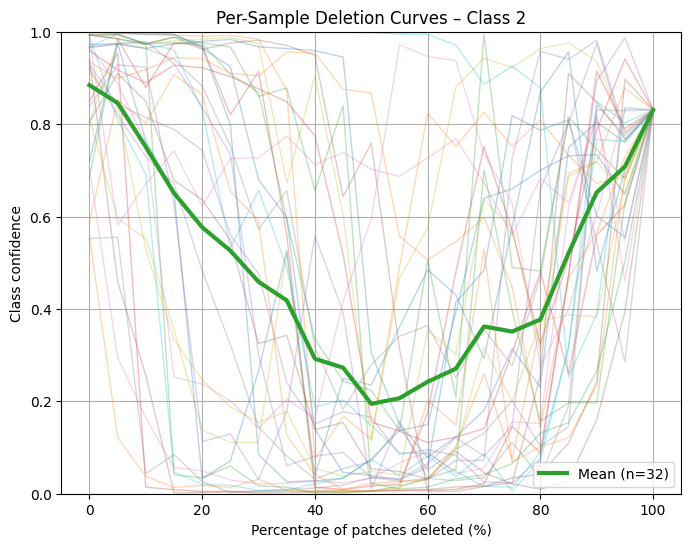

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


## Attention Rollout

#### Overall

curves shape: (116, 21)
percentages shape: (21,)


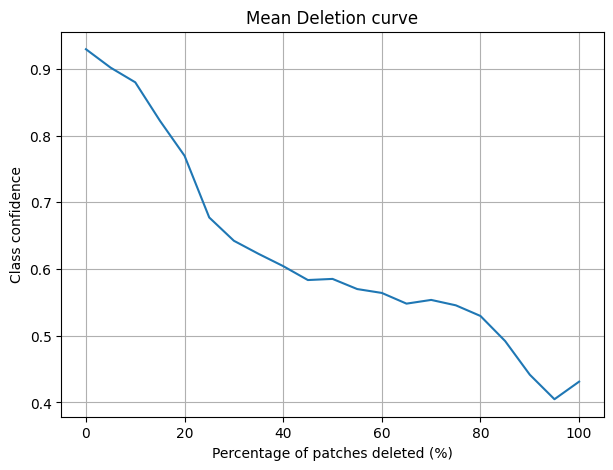

-----------------------
-----------------------
-----------------------


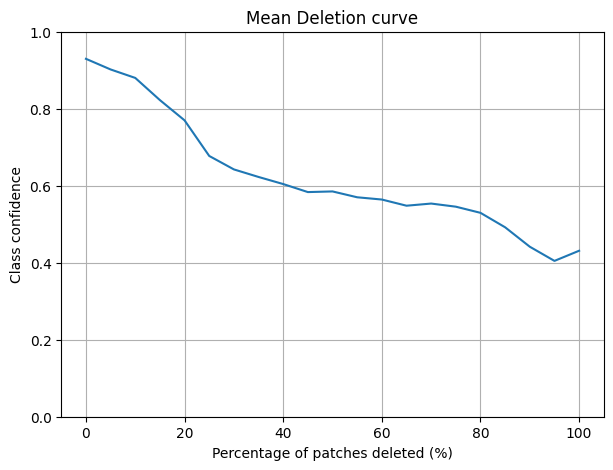

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Specify the method subdirectory (e.g., "attention_mask", "mean", "black", etc.)
method = "attention_mask"  # Change this to the desired method
curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

#### Overall - "BLACK"

In [ ]:
path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black/02F4A1FB_left_curve_black.npy")
data = np.load(path, allow_pickle=True).item()
list(data.keys())


['percentages',
 'confidences',
 'normalized_confidences',
 'predicted_class',
 'predicted_confidences',
 'predicted_normalized_confidences',
 'auc',
 'baseline']

In [ ]:
print(data['predicted_confidences'])
print(data['confidences'][:, -1:])

[0.5886417  0.3623032  0.2620221  0.03905889 0.03831822 0.03587325
 0.0489917  0.04567838 0.02285638 0.02285521 0.01819856 0.02755756
 0.06733793 0.058701   0.07117386 0.01518851 0.06946148 0.306531
 0.55028975 0.7340041  0.8305886 ]
[[0.5886417 ]
 [0.3623032 ]
 [0.2620221 ]
 [0.03905889]
 [0.03831822]
 [0.03587325]
 [0.0489917 ]
 [0.04567838]
 [0.02285638]
 [0.02285521]
 [0.01819856]
 [0.02755756]
 [0.06733793]
 [0.058701  ]
 [0.07117386]
 [0.01518851]
 [0.06946148]
 [0.306531  ]
 [0.55028975]
 [0.7340041 ]
 [0.8305886 ]]


curves shape: (116, 21)
percentages shape: (21,)


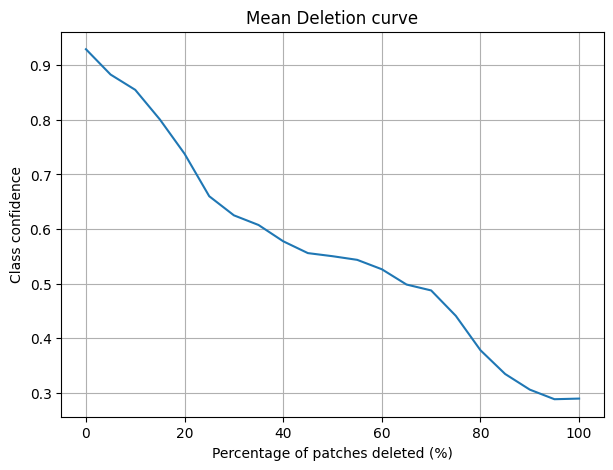

-----------------------
-----------------------
-----------------------


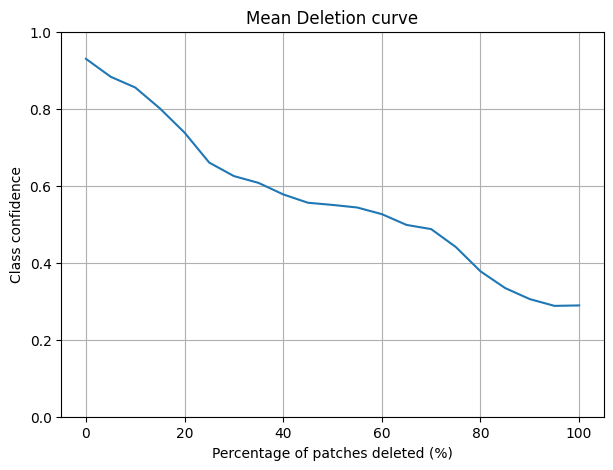

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

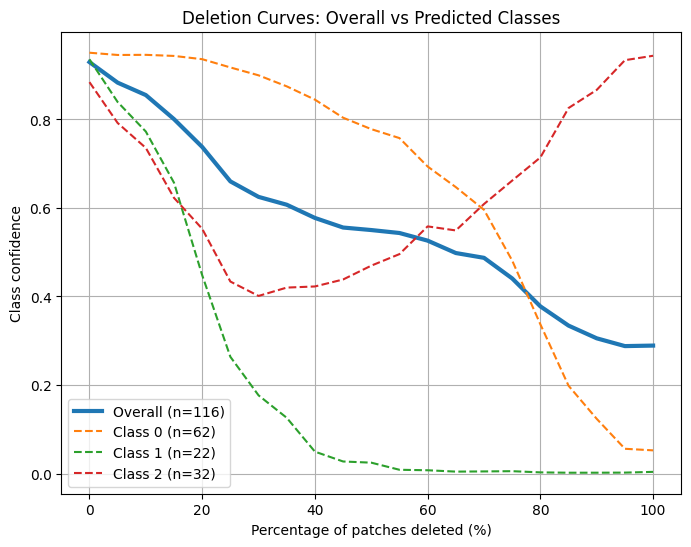

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention_rollout_black.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


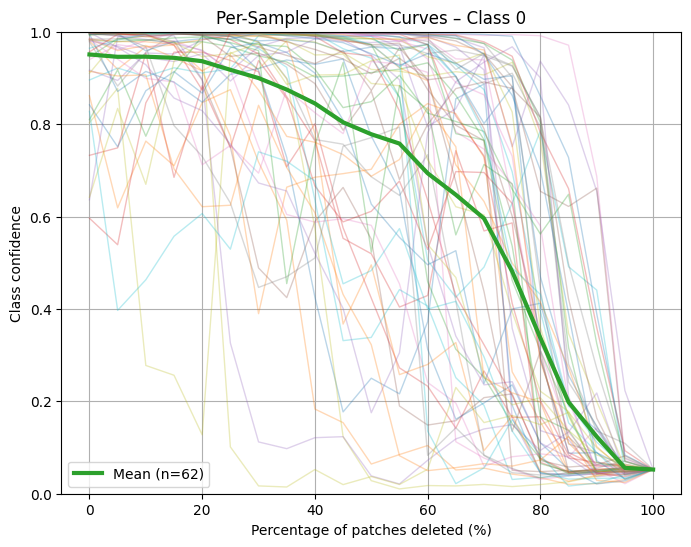

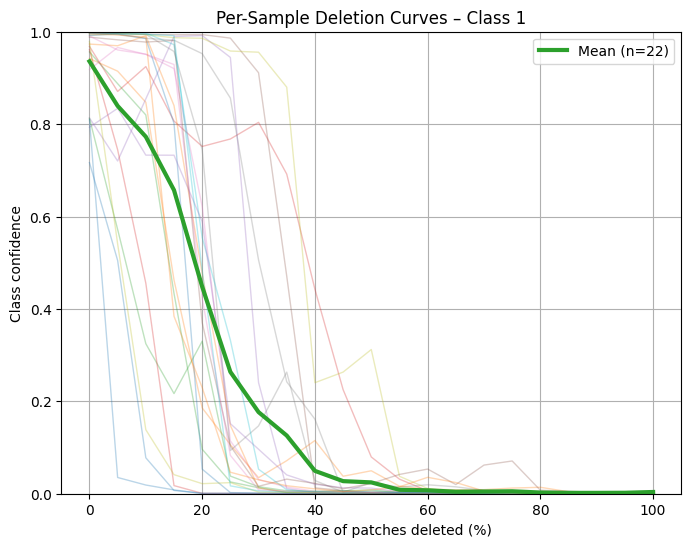

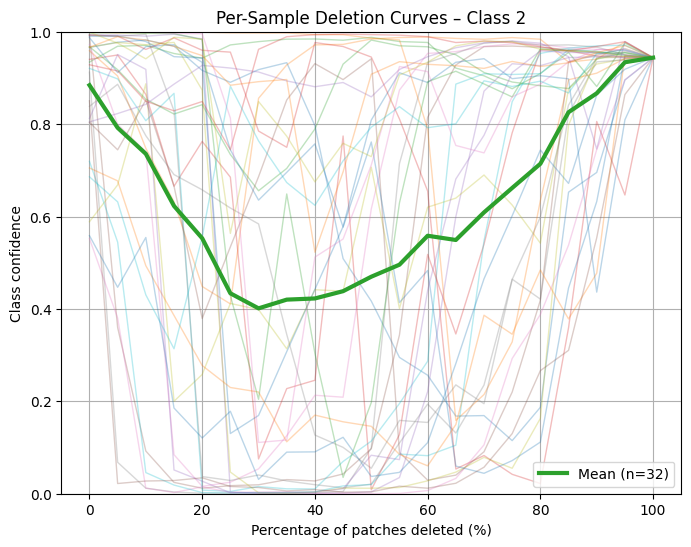

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


#### Mean Calculate Exclude Class 0

#### Overall - "BLACK-10"

In [ ]:
path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10/02F4A1FB_left_curve_black-10.npy")
data = np.load(path, allow_pickle=True).item()
list(data.keys())


['percentages',
 'confidences',
 'normalized_confidences',
 'predicted_class',
 'predicted_confidences',
 'predicted_normalized_confidences',
 'auc',
 'baseline']

In [ ]:
print(data['predicted_confidences'])
print(data['confidences'][:, -1:])

[0.5886417  0.63139194 0.67626965 0.6119058  0.6128641  0.6804478
 0.69337064 0.6602078  0.7023714  0.7271121  0.81714964 0.8153966
 0.8209574  0.3047334  0.26936623 0.28563857 0.26882854 0.25286812
 0.23378092 0.23522665 0.21017341 0.20742798 0.27104264 0.3580947
 0.3904811  0.3854391  0.37580356 0.36839056 0.38737935 0.3305865
 0.3167898  0.3639484  0.28542045 0.23630112 0.24170135 0.22856306
 0.23940168 0.20654109 0.15938908 0.18996708 0.15335466 0.14660704
 0.13817908 0.14386104 0.13069774 0.11523679 0.12750807 0.14851114
 0.1270021  0.12157955 0.09956774 0.0986048  0.11552177 0.11166251
 0.10101638 0.11152605 0.11164306 0.12567413 0.12403218 0.13042279
 0.11852174 0.12231343 0.12648022 0.13206422 0.13400793 0.12899426
 0.15686473 0.15939602 0.16138531 0.16984923 0.1854149  0.14624044
 0.17204751 0.182822   0.2019489  0.18366843 0.20065308 0.23909473
 0.2855092  0.2988806  0.29899096 0.4775016  0.44219124 0.49352902
 0.6149253  0.7290593  0.78418744 0.81859666 0.81484115 0.8533933


In [ ]:
print(data['predicted_class'])
print(data['predicted_normalized_confidences'])
print(data['normalized_confidences'][:, -1:])

2
[0.63716954 0.69275546 0.7511076  0.66741866 0.66866463 0.75654024
 0.7733431  0.7302232  0.78504634 0.8172154  0.93428653 0.93200713
 0.9392376  0.2680183  0.22203222 0.24319029 0.22133309 0.20058057
 0.17576249 0.17764229 0.14506687 0.14149712 0.22421198 0.3374012
 0.3795116  0.37295574 0.36042714 0.3507884  0.37547854 0.30163375
 0.28369462 0.3450125  0.24290667 0.17903937 0.18606101 0.16897796
 0.18307087 0.14034395 0.07903464 0.11879363 0.0711884  0.06241482
 0.05145638 0.05884434 0.04172879 0.02162571 0.03758143 0.06489062
 0.03692354 0.02987288 0.00125206 0.         0.02199625 0.01697826
 0.00313565 0.01680083 0.01695297 0.03519684 0.03306191 0.04137127
 0.02589696 0.03082711 0.03624497 0.04350555 0.04603285 0.03951383
 0.07575236 0.07904367 0.08163024 0.09263543 0.11287466 0.06193815
 0.09549374 0.10950325 0.13437296 0.11060382 0.13268808 0.18267176
 0.24302208 0.26040822 0.26055172 0.4926598  0.4467476  0.51349944
 0.67134476 0.8197472  0.89142746 0.936168   0.9312849  0.981

curves shape: (116, 101)
percentages shape: (101,)


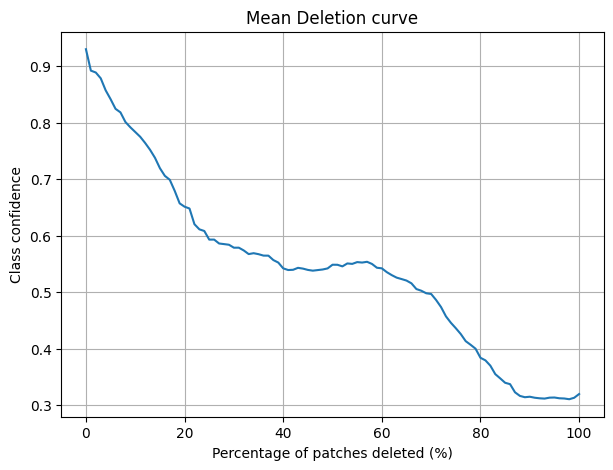

-----------------------
-----------------------
-----------------------


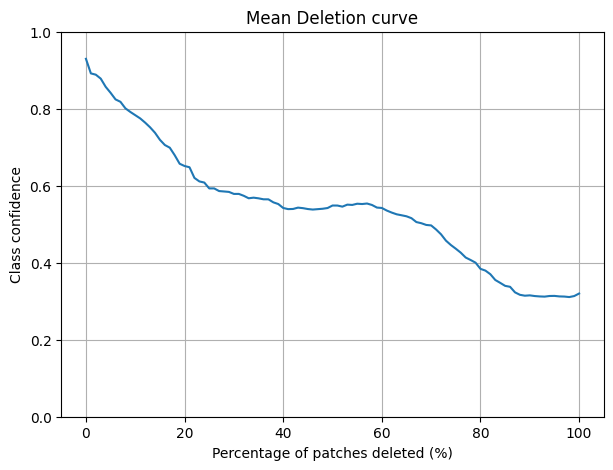

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

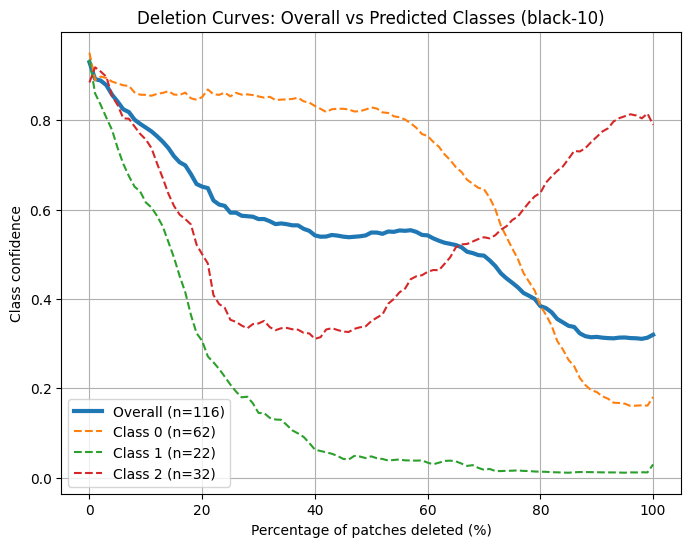

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention_rollout_black-10.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black-10", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes (black-10)")
plt.legend()
plt.grid(True)
plt.show()


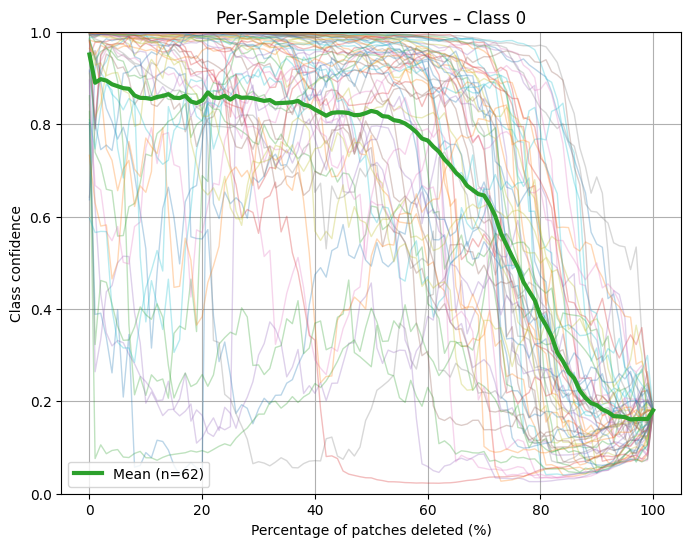

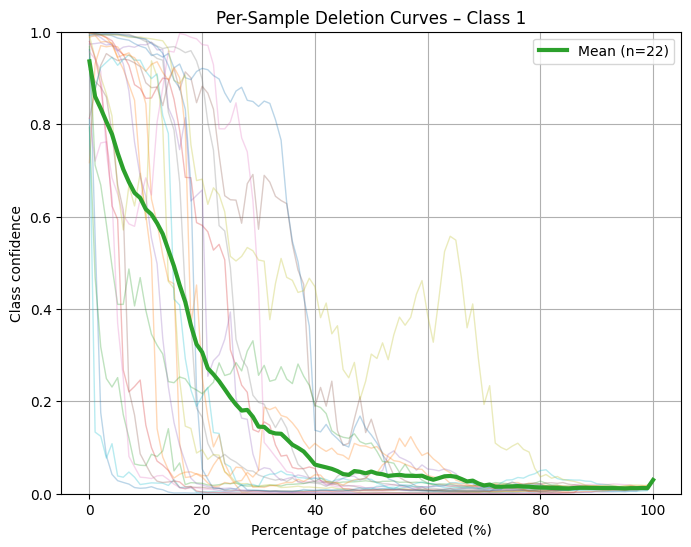

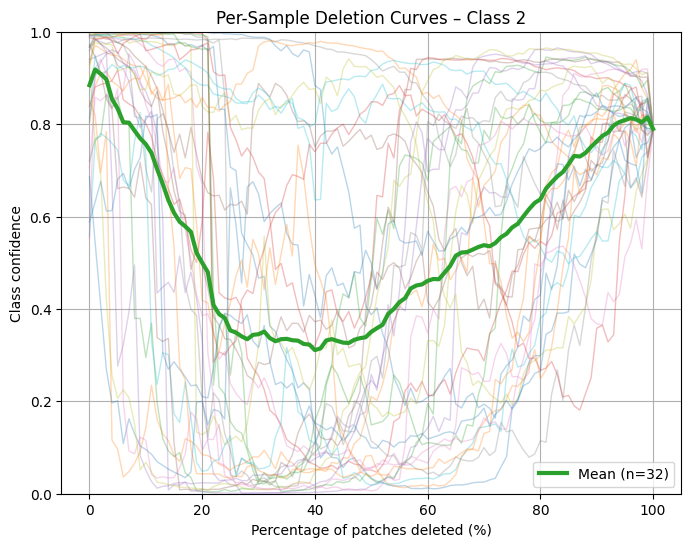

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


#### Each Class - Attention Mask


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

Class sizes: {2: 32, 0: 62, 1: 22}
Class weights: {2: 0.27586206896551724, 0: 0.5344827586206896, 1: 0.1896551724137931}


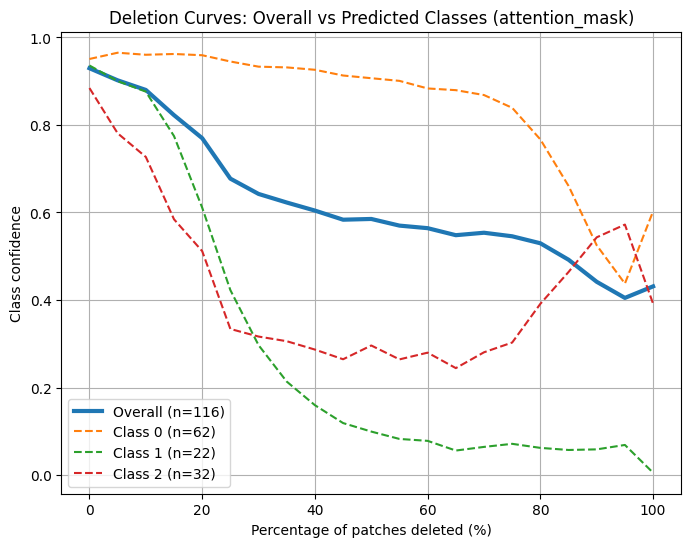

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

method = "attention_mask"  # Change this to the desired method (e.g., "attention_mask", "mean", "black-10", etc.)       
# Paths
curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}")
csv_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_attention_rollout_{method}.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace(f"_curve_{method}", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
# Calculate class weights based on number of samples
class_sizes = {cls: len(curves) for cls, curves in class_curves.items()}
total_samples = sum(class_sizes.values())
class_weights = {cls: size / total_samples for cls, size in class_sizes.items()}

print("Class sizes:", class_sizes)
print("Class weights:", class_weights)

all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title(f"Deletion Curves: Overall vs Predicted Classes ({method})")
plt.legend()
plt.grid(True)
plt.show()


Class sizes: {2: 32, 0: 62, 1: 22}
Total samples: 116
Macro weights (equal): {2: 0.3333333333333333, 0: 0.3333333333333333, 1: 0.3333333333333333}
Macro weights (%): {2: '33.3%', 0: '33.3%', 1: '33.3%'}
Class 2: 32 samples, macro weight=0.3333
Class 0: 62 samples, macro weight=0.3333
Class 1: 22 samples, macro weight=0.3333


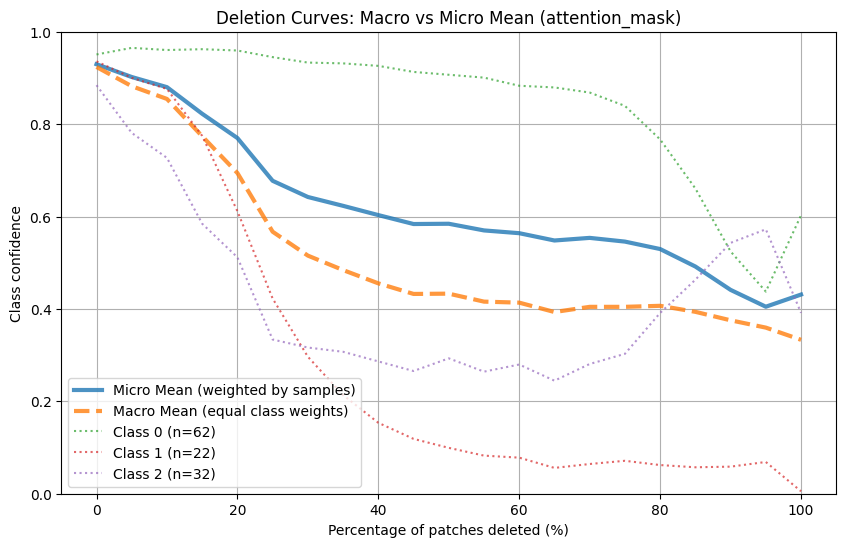


Micro Mean (sample-weighted):
[0.9296123  0.90198517 0.880015   0.8223831  0.7698672  0.6773
 0.6422985  0.6231087  0.6031023  0.58376056 0.5843425  0.5699101
 0.56391597 0.5481125  0.55377215 0.54573077 0.52958643 0.4917719
 0.44120324 0.40476954 0.431119  ]

Macro Mean (equal class weights):
[0.92365143 0.88209572 0.85449162 0.77372256 0.6941593  0.5671047
 0.51536999 0.48407647 0.45533569 0.4324339  0.43304247 0.41577791
 0.41358496 0.3933077  0.40448879 0.40451217 0.40673006 0.39371194
 0.37533754 0.35952957 0.33314723]


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

method = "attention_mask"  # Change this to the desired method
# Paths
curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}")
csv_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_attention_rollout_{method}.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace(f"_curve_{method}", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Calculate class sizes
class_sizes = {cls: len(curves) for cls, curves in class_curves.items()}
total_samples = sum(class_sizes.values())

# Macro mean: equal weight for each class (1/number_of_classes)
num_classes = len(class_curves)
macro_weights = {cls: 1.0 / num_classes for cls in class_curves.keys()}

print("Class sizes:", class_sizes)
print("Total samples:", total_samples)
print("Macro weights (equal):", macro_weights)
print("Macro weights (%):", {cls: f"{weight*100:.1f}%" for cls, weight in macro_weights.items()})

# Calculate macro mean (each class contributes equally)
macro_mean = np.zeros_like(list(class_curves.values())[0][0], dtype=float)

for cls, curves in class_curves.items():
    curves_array = np.array(curves)
    class_mean = curves_array.mean(axis=0)
    macro_mean += macro_weights[cls] * class_mean
    print(f"Class {cls}: {len(curves)} samples, macro weight={macro_weights[cls]:.4f}")

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(10, 6))

# Simple mean (micro-averaged - weighted by sample count)
all_curves = np.concatenate([np.array(curves) for curves in class_curves.values()])
micro_mean = all_curves.mean(axis=0)
plt.plot(x_percent, micro_mean, linewidth=3, label="Micro Mean (weighted by samples)", linestyle='-', alpha=0.8)

# Macro mean (each class contributes equally)
plt.plot(x_percent, macro_mean, linewidth=3, label="Macro Mean (equal class weights)", linestyle='--', alpha=0.8)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves_array = np.array(curves)
    class_mean = curves_array.mean(axis=0)
    plt.plot(
        x_percent,
        class_mean,
        linestyle=":",
        alpha=0.7,
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title(f"Deletion Curves: Macro vs Micro Mean ({method})")
plt.legend(loc='best')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

print("\nMicro Mean (sample-weighted):")
print(micro_mean)
print("\nMacro Mean (equal class weights):")
print(macro_mean)

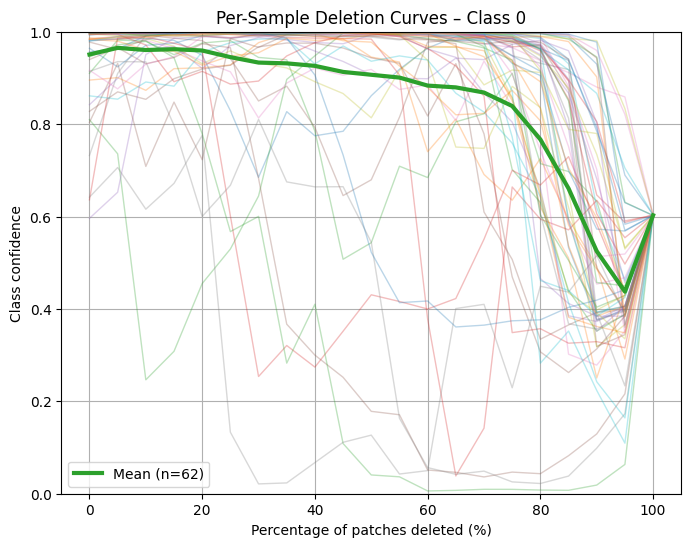

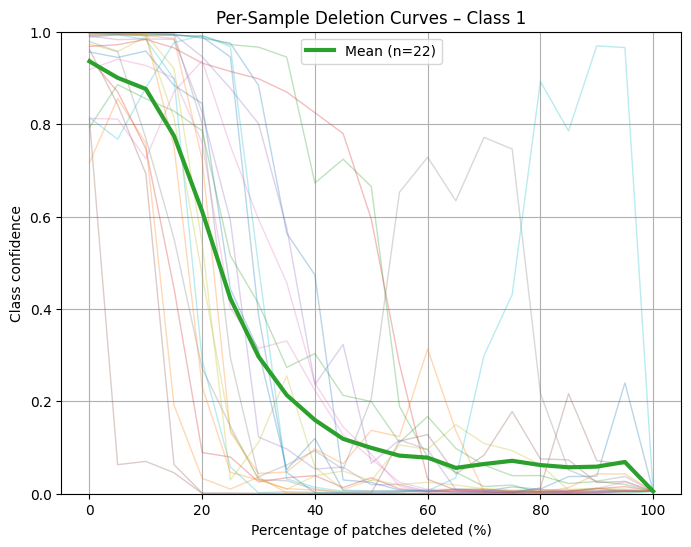

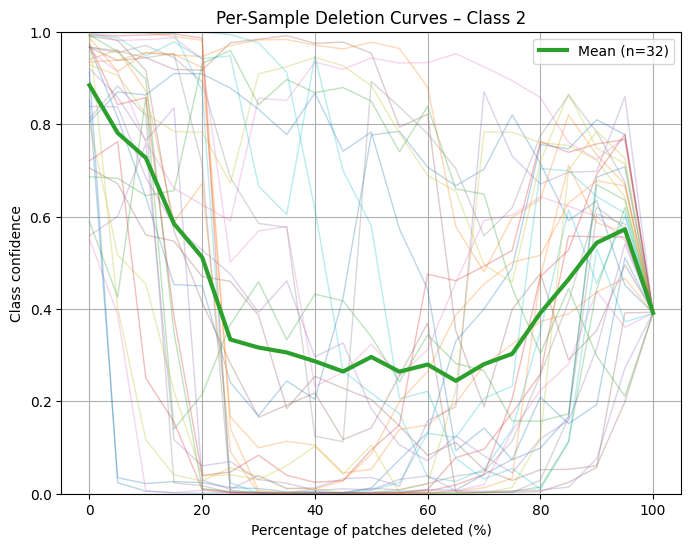

In [2]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


### ภาพรวม

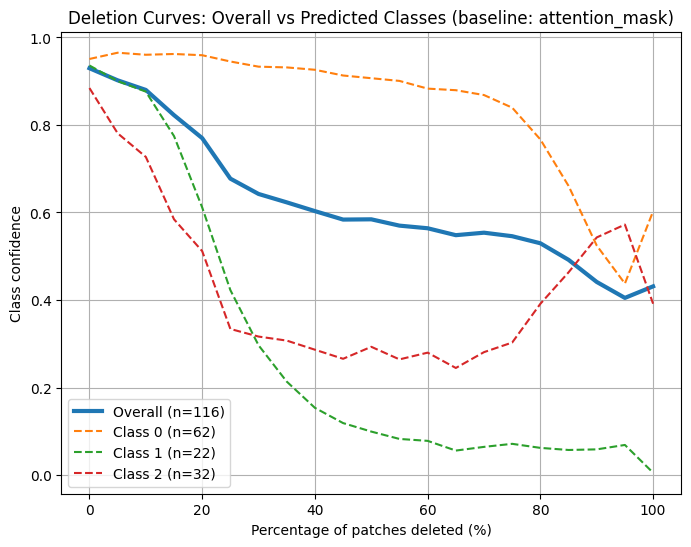

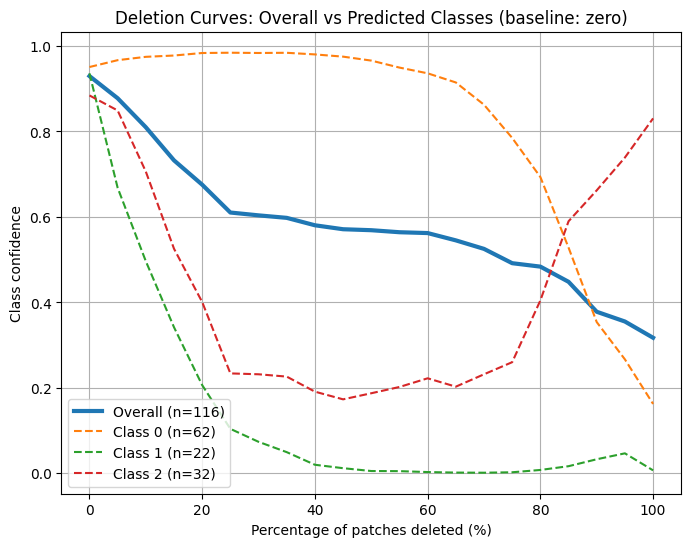

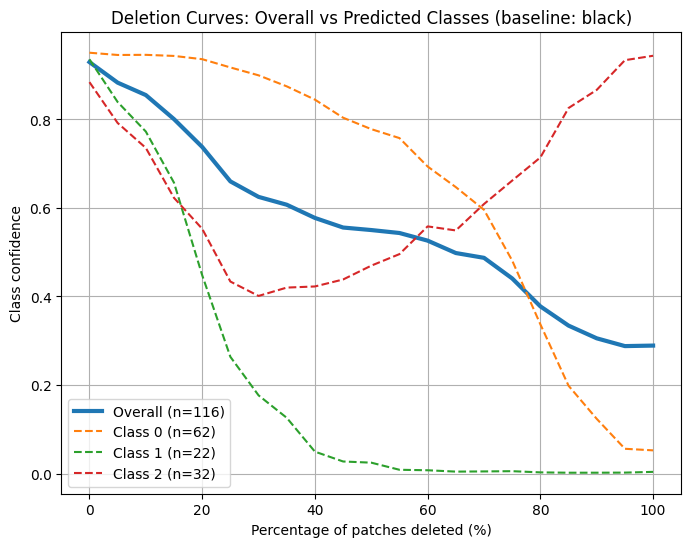

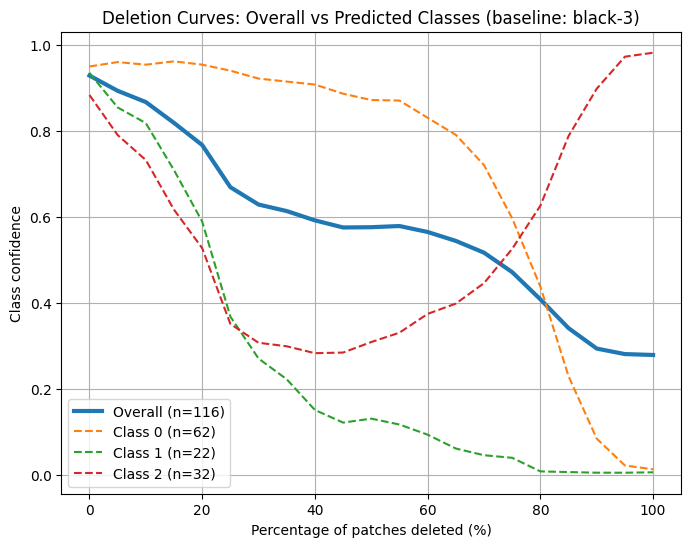

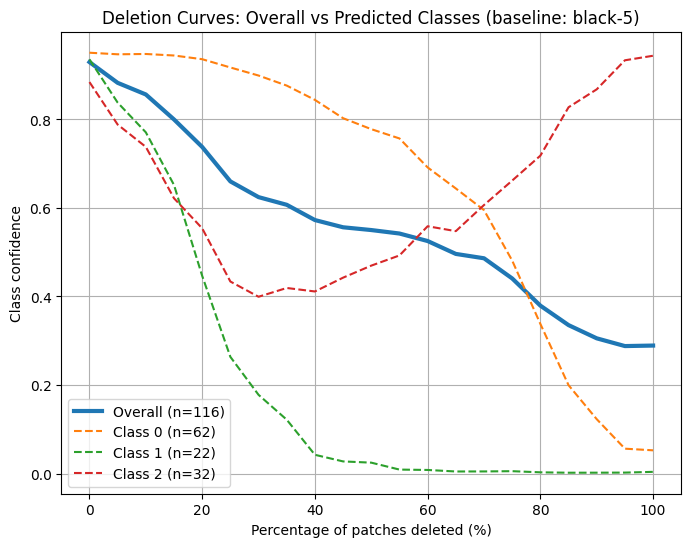

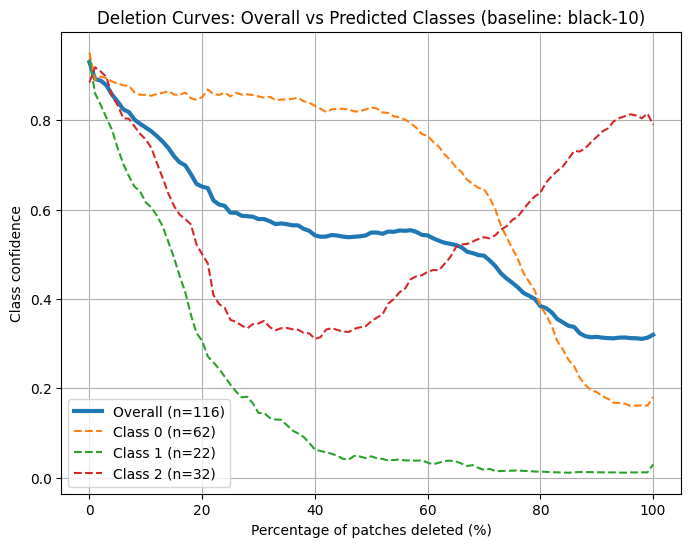

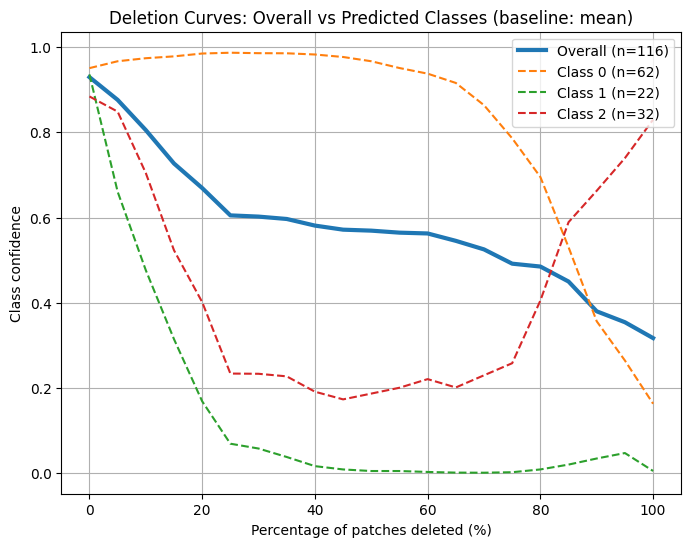

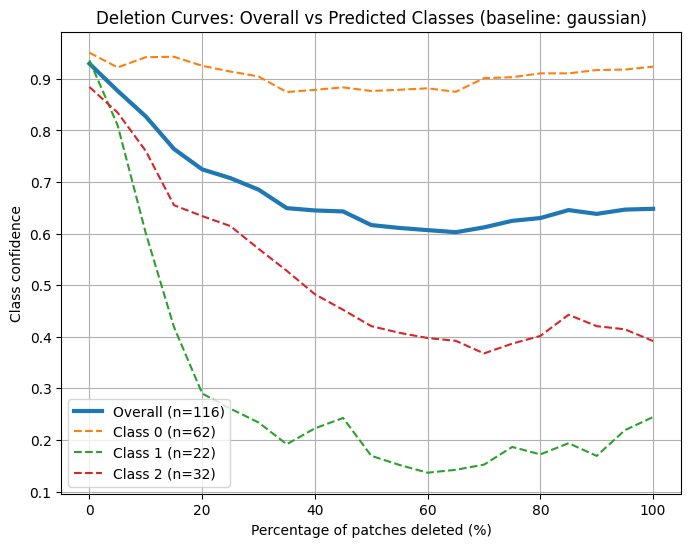

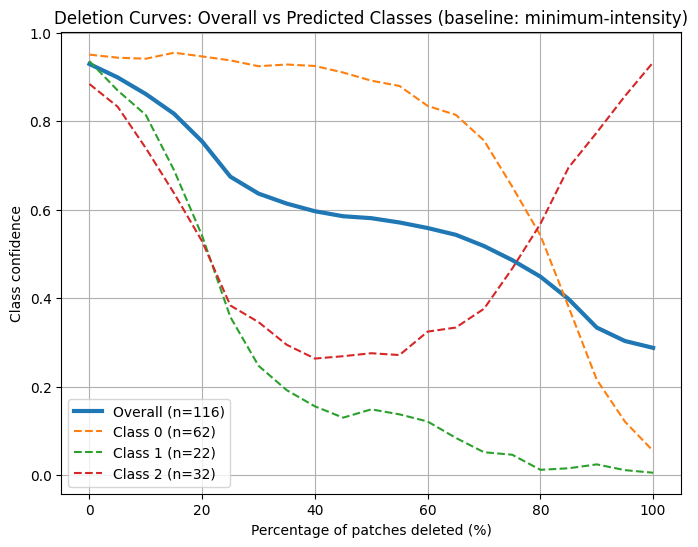

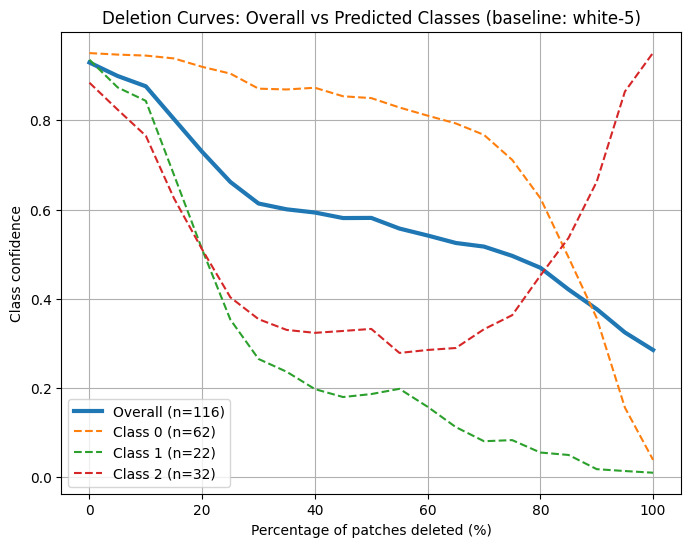

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(
    "/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/"
    "evaluation_results/deletion"
)

BASELINES = {
    "attention_mask": "attention_mask",
    "zero": "zero",
    "black": "black",
    "black-3": "black-3",
    "black-5": "black-5",
    "black-10": "black-10",
    "mean": "mean",
    "gaussian": "gaussian",
    "minimum-intensity": "minimum-intensity",
    "white-5": "white-5",

}

for baseline in BASELINES.values():
    curve_dir = BASE_DIR / "deletion_curves" / "attention_rollout" / baseline
    csv_path = BASE_DIR /  f"deletion_attention_rollout_{baseline}.csv"

    # Load CSV
    df = pd.read_csv(csv_path)
    uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

    all_curves = []
    class_curves = {}
    percentages = None

    # Load curves
    for f in curve_dir.glob("*.npy"):
        if baseline == "zero":
            uid = f.stem.replace("_curve", "")
        else:
            uid = f.stem.replace(f"_curve_{baseline}", "")
        
        if uid not in uid_to_class:
            continue

        data = np.load(f, allow_pickle=True).item()
        confidences = data["predicted_confidences"]
        
        all_curves.append(confidences)
        
        cls = uid_to_class[uid]
        if cls not in class_curves:
            class_curves[cls] = []
        class_curves[cls].append(confidences)
        
        if percentages is None:
            percentages = data["percentages"]

    # Safety check
    if len(all_curves) == 0:
        print(f"Warning: No matching curves found for baseline '{baseline}'. Skipping.")
        raise ValueError(f"No matching curves found for baseline '{baseline}'.")

    # Convert to numpy
    all_curves = np.array(all_curves)
    overall_mean = all_curves.mean(axis=0)

    # Plot
    x_percent = np.array(percentages) * 100
    plt.figure(figsize=(8, 6))

    # Overall curve (thicker line)
    plt.plot(
        x_percent,
        overall_mean,
        linewidth=3,
        label=f"Overall (n={len(all_curves)})"
    )

    # Per-class curves
    for cls, curves in sorted(class_curves.items()):
        curves = np.array(curves)
        mean_curve = curves.mean(axis=0)
        plt.plot(
            x_percent,
            mean_curve,
            linestyle="--",
            label=f"Class {cls} (n={len(curves)})"
        )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title("Deletion Curves: Overall vs Predicted Classes (baseline: {})".format(baseline))
    plt.legend()
    plt.grid(True)
    plt.show()
